# Loading and Preprocessing MNIST Handwritten Digit Dataset:

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train, x_test = x_train / 255.0, x_test / 255.0
print(x_train.shape)

x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)


# Build the Model:

## 1. Sequential API

In [2]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
num_classes = 10
input_shape = (28*28, )
model = keras.Sequential(
[
keras.layers.Input(shape=input_shape),
keras.layers.Flatten(), # Flatten the 28x28 image to a 784-dimensional vector
keras.layers.Dense(64, activation="sigmoid"),
keras.layers.Dense(128, activation="sigmoid"),
keras.layers.Dense(256, activation="sigmoid"),
keras.layers.Dense(num_classes, activation="softmax"),
]
)

In [3]:
model.summary()
# 784 * 64 + 64 = 50,240
# 64 * 128 + 128 + 8,320

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model.compile(
optimizer="sgd", # Stochastic Gradient Descent
loss="categorical_crossentropy", # Loss function for multi-class classification
metrics=["accuracy"] # Track accuracy during training
)

In [5]:
batch_size = 128 # no.of batch - total/ batch_size
epochs = 100
# Callbacks
callbacks = [
  keras.callbacks.ModelCheckpoint(filepath="model_at_epoch_{epoch}.keras"),
  keras.callbacks.EarlyStopping(monitor="val_loss", patience=4 ),
]
# Train the model with callbacks and validation split
history = model.fit(
  x_train,
  y_train,
  batch_size=batch_size,
  epochs=epochs,
  validation_split=0.15,
  callbacks=callbacks,
)

Epoch 1/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1113 - loss: 2.3076 - val_accuracy: 0.1093 - val_loss: 2.3038
Epoch 2/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1122 - loss: 2.3015 - val_accuracy: 0.1184 - val_loss: 2.3013
Epoch 3/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1168 - loss: 2.2999 - val_accuracy: 0.1102 - val_loss: 2.3001
Epoch 4/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1217 - loss: 2.2984 - val_accuracy: 0.1063 - val_loss: 2.2982
Epoch 5/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1212 - loss: 2.2964 - val_accuracy: 0.1728 - val_loss: 2.2976
Epoch 6/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.1270 - loss: 2.2948 - val_accuracy: 0.1063 - val_loss: 2.2948
Epoch 7/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1259 - loss: 2.2928 - val_accuracy: 0.1063 - val_loss: 2.2922
Epoch 8/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1392 - loss: 2.2907 - val_accu

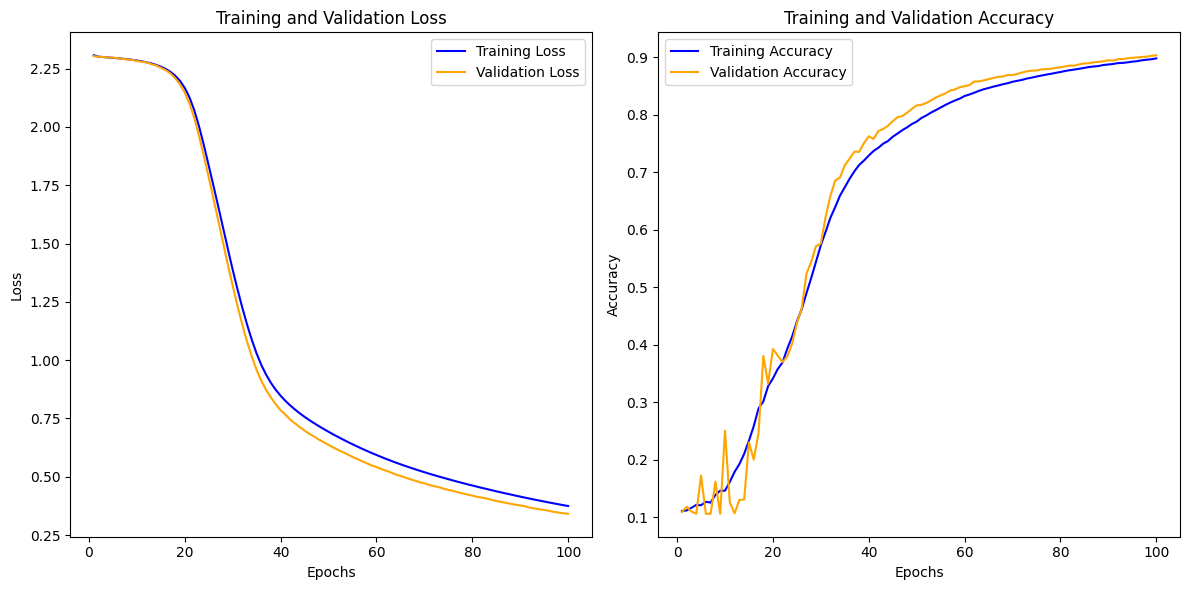

In [6]:
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss', color='blue')
plt.plot(range(1, len(val_loss) + 1), val_loss, label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy', color='blue')
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc:.4f}")

313/313 - 1s - 2ms/step - accuracy: 0.8989 - loss: 0.3643
Test accuracy: 0.8989


# Exercise: Building a Fully Connected Network (FCN) for Devnagari Digit Classification.

## Task 1: Data Preparation


### Loading libraries and extraction

In [8]:
import os
import numpy as np
from PIL import Image
from tensorflow.keras.utils import to_categorical

In [13]:
base_path = "/content/drive/MyDrive/AI and Machine Learning/Week4/unzipped_data/DevanagariHandwrittenDigitDataset"

train_dir = os.path.join(base_path, "Train")
test_dir = os.path.join(base_path, "Test")

### Load and read image files

In [16]:
from PIL import Image
import numpy as np

def load_data(data_dir, img_size=(28, 28)):
    X = []
    y = []

    for folder in os.listdir(data_dir):
        folder_path = os.path.join(data_dir, folder)

        if not os.path.isdir(folder_path):
            continue

        # Extract label from "digit_3" → 3
        label = int(folder.split("_")[1])

        for file in os.listdir(folder_path):
            img_path = os.path.join(folder_path, file)

            try:
                img = Image.open(img_path).convert('L')  # grayscale
                img = img.resize(img_size)
                img_array = np.array(img)

                X.append(img_array)
                y.append(label)

            except:
                continue

    return np.array(X), np.array(y)

### Loss Train/Test Data and normalize

In [17]:
X_train, y_train = load_data(train_dir)
X_test, y_test = load_data(test_dir)

In [18]:
X_train = X_train / 255.0
X_test = X_test / 255.0

### Flatten for FCN

In [19]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

### One-Hot Encoding

In [20]:
from tensorflow.keras.utils import to_categorical

num_classes = 10  # digits 0–9

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

In [21]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (17000, 784)
y_train: (17000, 10)
X_test: (3000, 784)
y_test: (3000, 10)


In [22]:
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

X_train, y_train = shuffle(X_train, y_train, random_state=42)

# Split training into train and validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

## Task 2: Build FCN Model

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

# Input layer and Hidden Layer 1
model.add(Dense(64, activation='sigmoid', input_shape=(784,)))
# Hidden Layer 2
model.add(Dense(128, activation='sigmoid'))
# Hidden Layer 3
model.add(Dense(256, activation='sigmoid'))
# Output Layer
model.add(Dense(10, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile the model

In [24]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Task 4: Train

In [25]:
history = model.fit(
    X_train_final, y_train_final,
    batch_size=128,
    epochs=20,
    validation_data=(X_val, y_val)
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4046 - loss: 1.8507 - val_accuracy: 0.7288 - val_loss: 1.0604
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8099 - loss: 0.6892 - val_accuracy: 0.8659 - val_loss: 0.4458
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8949 - loss: 0.3575 - val_accuracy: 0.9174 - val_loss: 0.2888
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9357 - loss: 0.2375 - val_accuracy: 0.9379 - val_loss: 0.2128
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9509 - loss: 0.1756 - val_accuracy: 0.9497 - val_loss: 0.1738
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9626 - loss: 0.1381 - val_accuracy: 0.9559 - val_loss: 0.1483
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9691 - loss: 0.1122 - val_accuracy: 0.9618 - val_loss: 0.1292
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9770 - loss: 0.0915 - val_accuracy: 0.

## Visualization

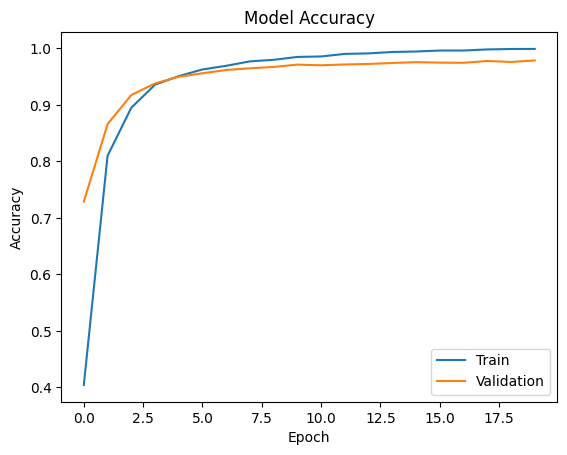

In [26]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()


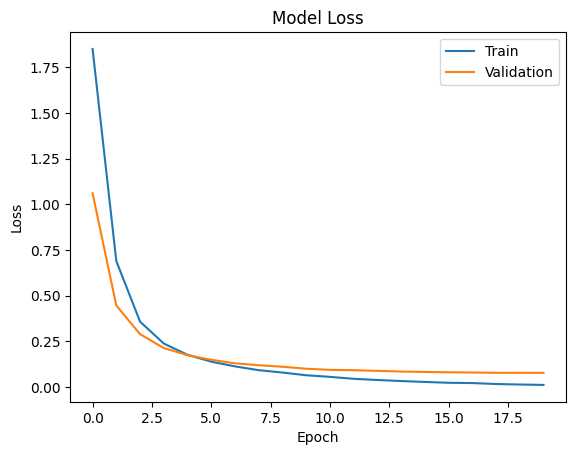

In [27]:
# Loss graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# Task 5: Evaluation

In [28]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9753 - loss: 0.0889
Test Loss: 0.08891447633504868
Test Accuracy: 0.9753333330154419


# Task 6: Save and Load the Model

In [29]:
model.save("devnagari_fcn_model.keras")
print("Model saved!")

Model saved!


In [35]:
from tensorflow.keras.models import load_model

loaded_model = load_model("devnagari_fcn_model.keras")
print("Model loaded successfully!")

Model loaded successfully!


In [36]:
loss, accuracy = loaded_model.evaluate(X_test, y_test)

print("Test Data Loss:", loss)
print("Test Accuracy:", accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9753 - loss: 0.0889
Test Data Loss: 0.08891447633504868
Test Accuracy: 0.9753333330154419


# Task 7: Predictions

In [37]:
predictions = loaded_model.predict(X_test)

# Convert probabilities → labels
predicted_labels = np.argmax(predictions, axis=1)

# True labels (convert from one-hot)
true_labels = np.argmax(y_test, axis=1)

print("Predicted:", predicted_labels[:10])
print("Actual:", true_labels[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: [0 0 0 0 0 0 0 0 0 0]
Actual: [0 0 0 0 0 0 0 0 0 0]


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
